# Quantitative Framework Across Window Sizes

This notebook applies the shared WES-vs-in situ quantitative validation framework across saved in situ CNV profiles generated with different window sizes.


## Inputs


In [1]:
from pathlib import Path

wes_file = Path('/home/augusta/storage3/augusta/insituCNV/data_from_Kang/sample_selection/WES_PureCN/WES_PureCN_output.csv')
notebook_dir = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_window_sizes')
results_dir = notebook_dir / 'results' / 'average_tumor_CNV_values_per_gene'
output_dir = notebook_dir / 'results' / 'wes_vs_insitu_metrics'

sample_name = '1105_BL'
bin_size_bp = 20_000_000
min_genes_per_bin = 5
parameter_pattern = r'window(\d+)'
parameter_name = 'window_size'
parameter_label = 'window_size'
label_prefix = 'window'


In [2]:
import sys
import pandas as pd
import seaborn as sns

repo_root = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from insitucnv.tl.quantitative_validation import (
    build_output_path,
    discover_gene_profile_runs,
    evaluate_wes_insitu_parameter_sweep,
    load_wes_segments,
    plot_multi_run_profile_lines,
    plot_multi_run_profile_stack,
    plot_parameter_metric_bars,
    plot_parameter_metric_summary,
    plot_parameter_threshold_curves,
    resolve_wes_sample_id,
    save_dataframe,
)

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)
output_dir.mkdir(parents=True, exist_ok=True)


## Load Runs And Evaluate The Framework


In [3]:
preview_paths = sorted(results_dir.glob('*.csv'))
if not preview_paths:
    raise ValueError(f'No saved in situ runs found in {results_dir}')

wes_sample_id = resolve_wes_sample_id(sample_name, wes_file)
wes = load_wes_segments(wes_file, wes_sample_id)
runs = discover_gene_profile_runs(
    results_path=results_dir,
    sample_name=sample_name,
    pattern=parameter_pattern,
    parameter_name=parameter_name,
    label_prefix=label_prefix,
)

if not wes:
    raise ValueError(f'No WES rows found for {wes_sample_id}')
if not runs:
    raise ValueError(f'No matching runs found for {sample_name} in {results_dir}')

run_results, all_metrics_df, all_wes_grid_df, all_insitu_grid_df = evaluate_wes_insitu_parameter_sweep(
    runs=runs,
    wes=wes,
    sample_name=sample_name,
    wes_sample_id=wes_sample_id,
    bin_size_bp=bin_size_bp,
    min_genes_per_bin=min_genes_per_bin,
    parameter_name=parameter_name,
)

if all_metrics_df.empty:
    raise ValueError('The framework did not produce any valid metric tables for the discovered runs.')

print('Comparing saved runs:', [run['run_label'] for run in run_results])
display(all_metrics_df[['run_label', 'window_size', 'wes_threshold', 'insitu_threshold', 'auc_mean', 'f1_mean', 'precision_mean', 'recall_mean']])


Comparing saved runs: ['window5', 'window10', 'window40', 'window60', 'window80', 'window100', 'window300']


,run_label,window_size,wes_threshold,insitu_threshold,auc_mean,f1_mean,precision_mean,recall_mean
0,window5,5,0.103615,0.019193,0.873475,0.317873,0.319251,0.687500
1,window10,10,0.103615,0.012712,0.891481,0.446695,0.490357,0.800000
2,window40,40,0.103615,0.034025,0.965411,0.813665,0.812500,0.836667
3,window60,60,0.103615,0.037862,0.972686,0.815476,0.790761,0.856667
4,window80,80,0.103615,0.031954,0.966635,0.675294,0.621818,0.773333
5,window100,100,0.103615,0.012152,0.962304,0.633333,0.507143,0.876667
6,window300,300,0.011416,0.000107,0.750181,0.626755,0.604825,0.723479


## Export Tables


In [4]:
save_dataframe(all_metrics_df, output_dir, sample_name, 'all_runs_metrics_summary', index=False, run_label='all_runs')
save_dataframe(all_wes_grid_df, output_dir, sample_name, 'all_runs_wes_threshold_auc_grid', index=False, run_label='all_runs')
save_dataframe(all_insitu_grid_df, output_dir, sample_name, 'all_runs_insitu_threshold_f1_grid', index=False, run_label='all_runs')

for run in run_results:
    save_dataframe(run['metric_df'], output_dir, sample_name, 'comparison_rows', index=False, run_label=run['run_label'])

display(all_metrics_df[['run_label', 'window_size', 'auc_mean', 'f1_mean', 'precision_mean', 'recall_mean']])


,run_label,window_size,auc_mean,f1_mean,precision_mean,recall_mean
0,window5,5,0.873475,0.317873,0.319251,0.687500
1,window10,10,0.891481,0.446695,0.490357,0.800000
2,window40,40,0.965411,0.813665,0.812500,0.836667
3,window60,60,0.972686,0.815476,0.790761,0.856667
4,window80,80,0.966635,0.675294,0.621818,0.773333
5,window100,100,0.962304,0.633333,0.507143,0.876667
6,window300,300,0.750181,0.626755,0.604825,0.723479


## Sweep Summaries


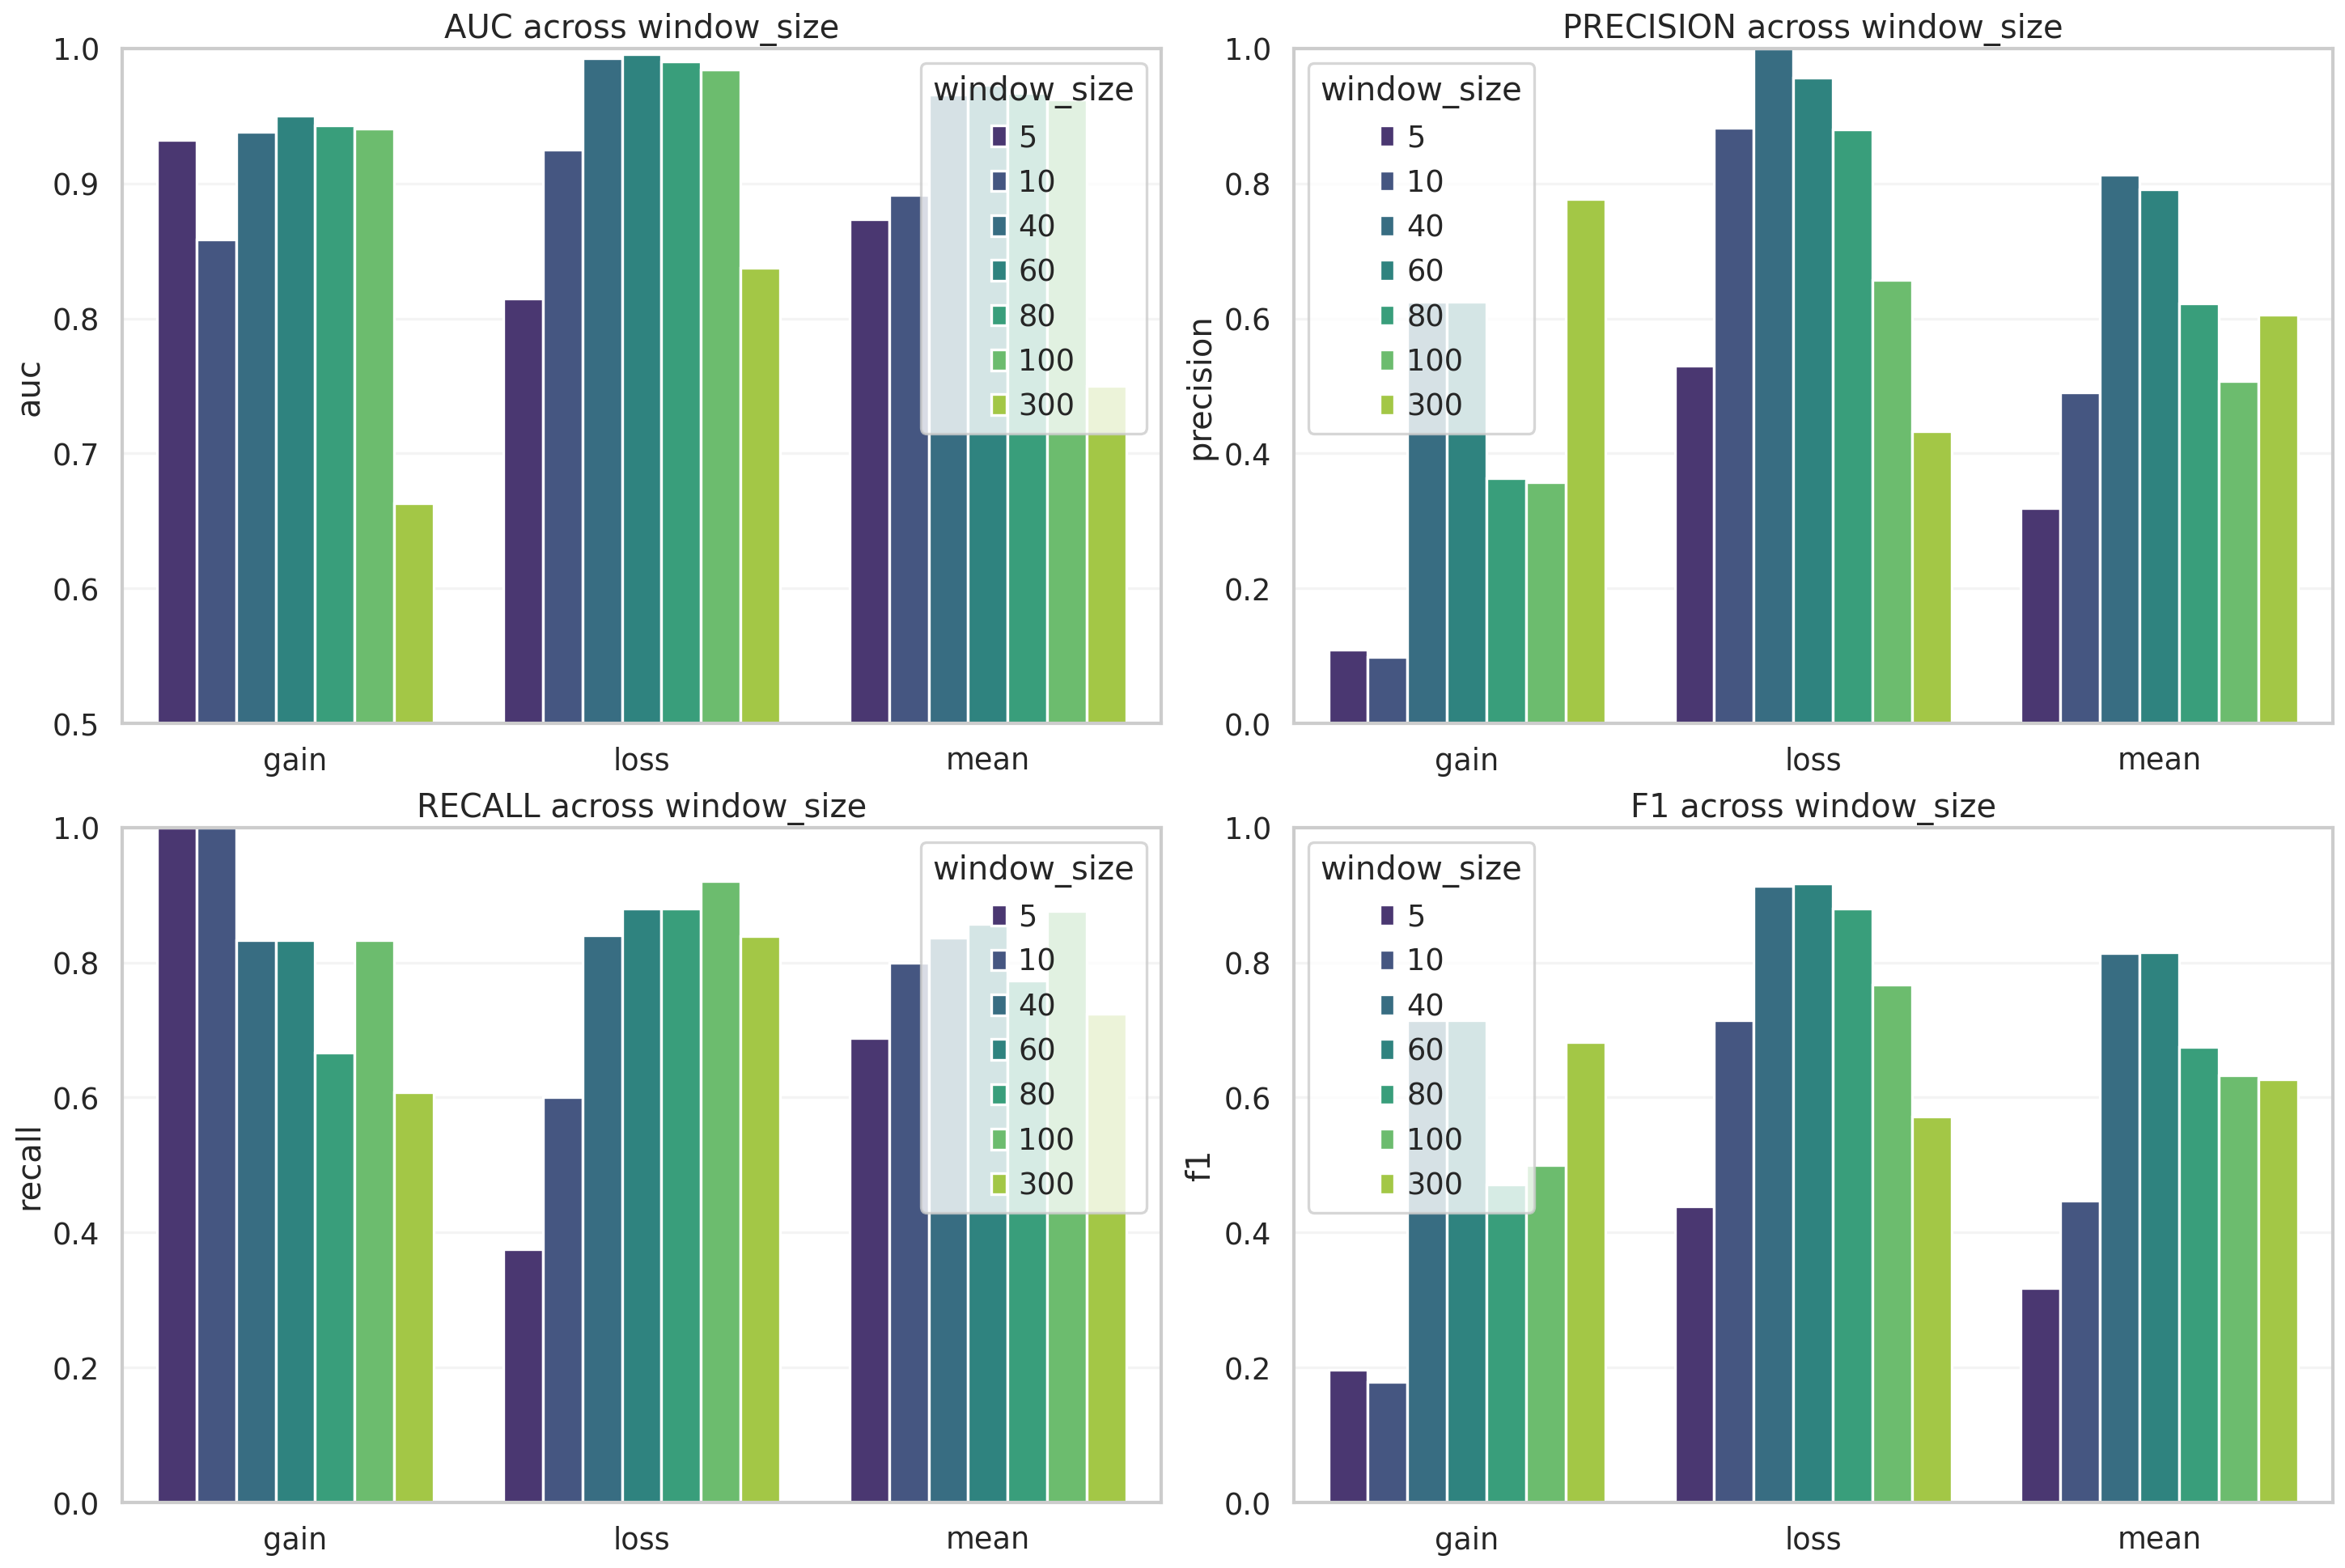

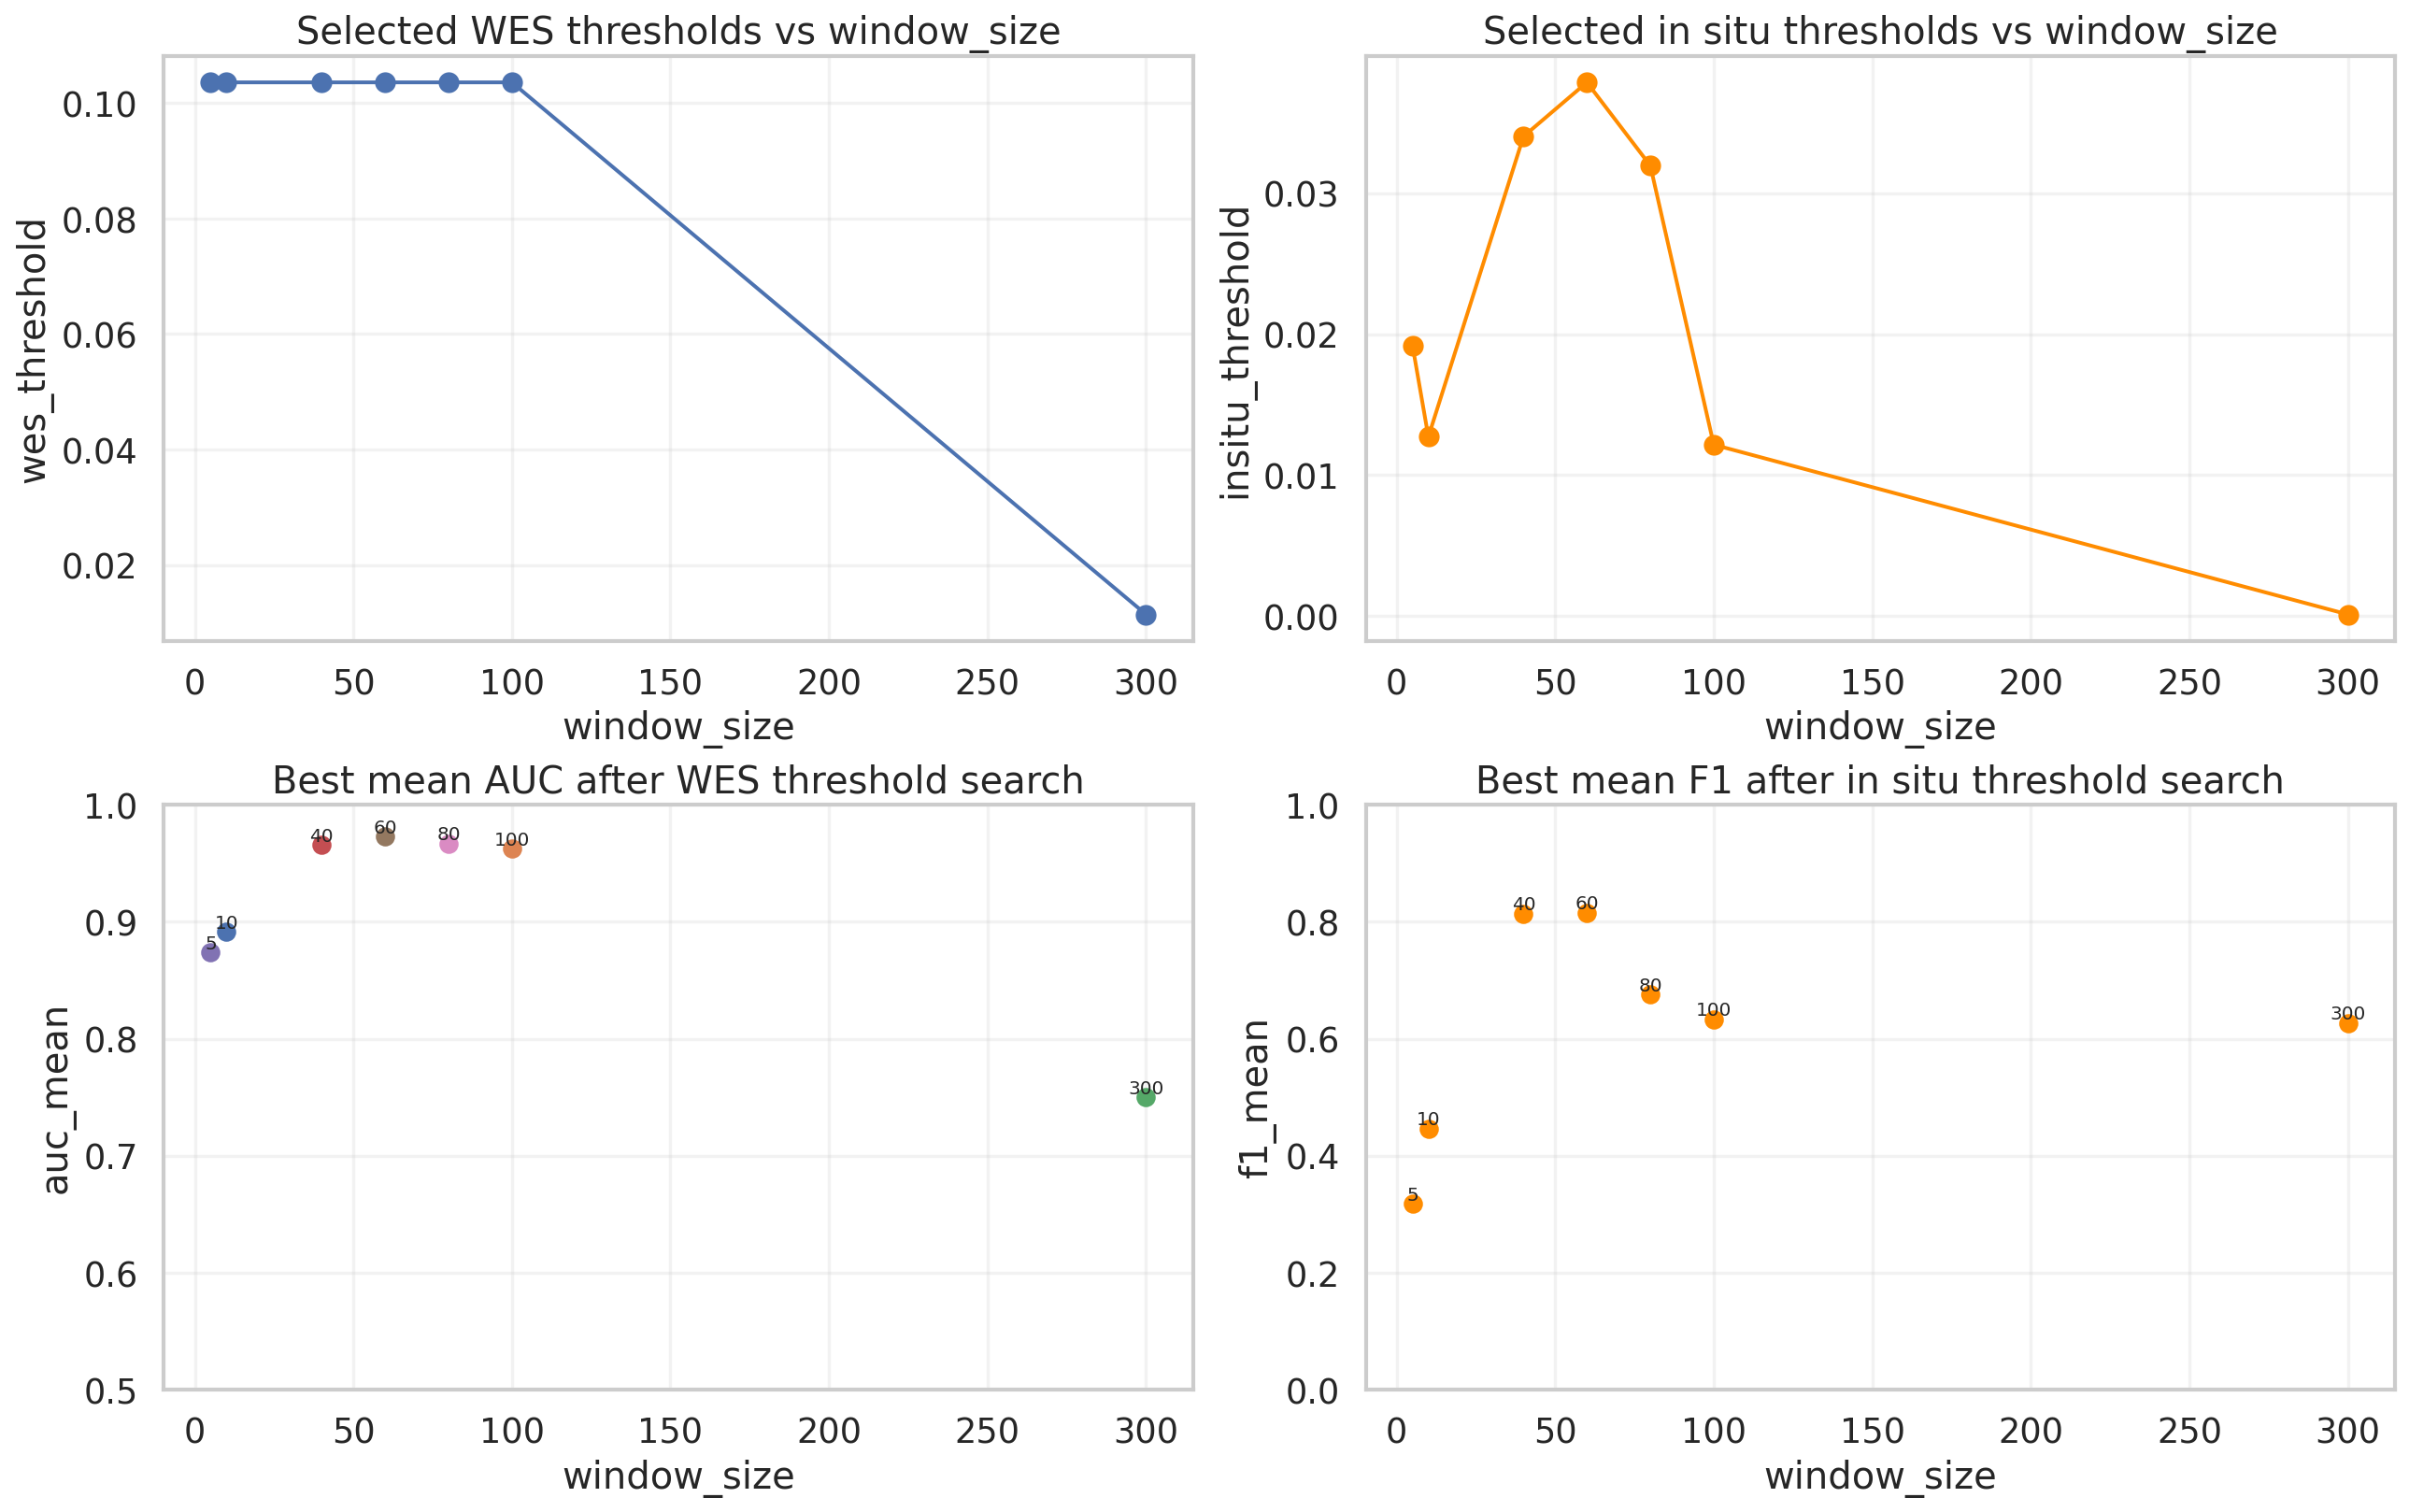

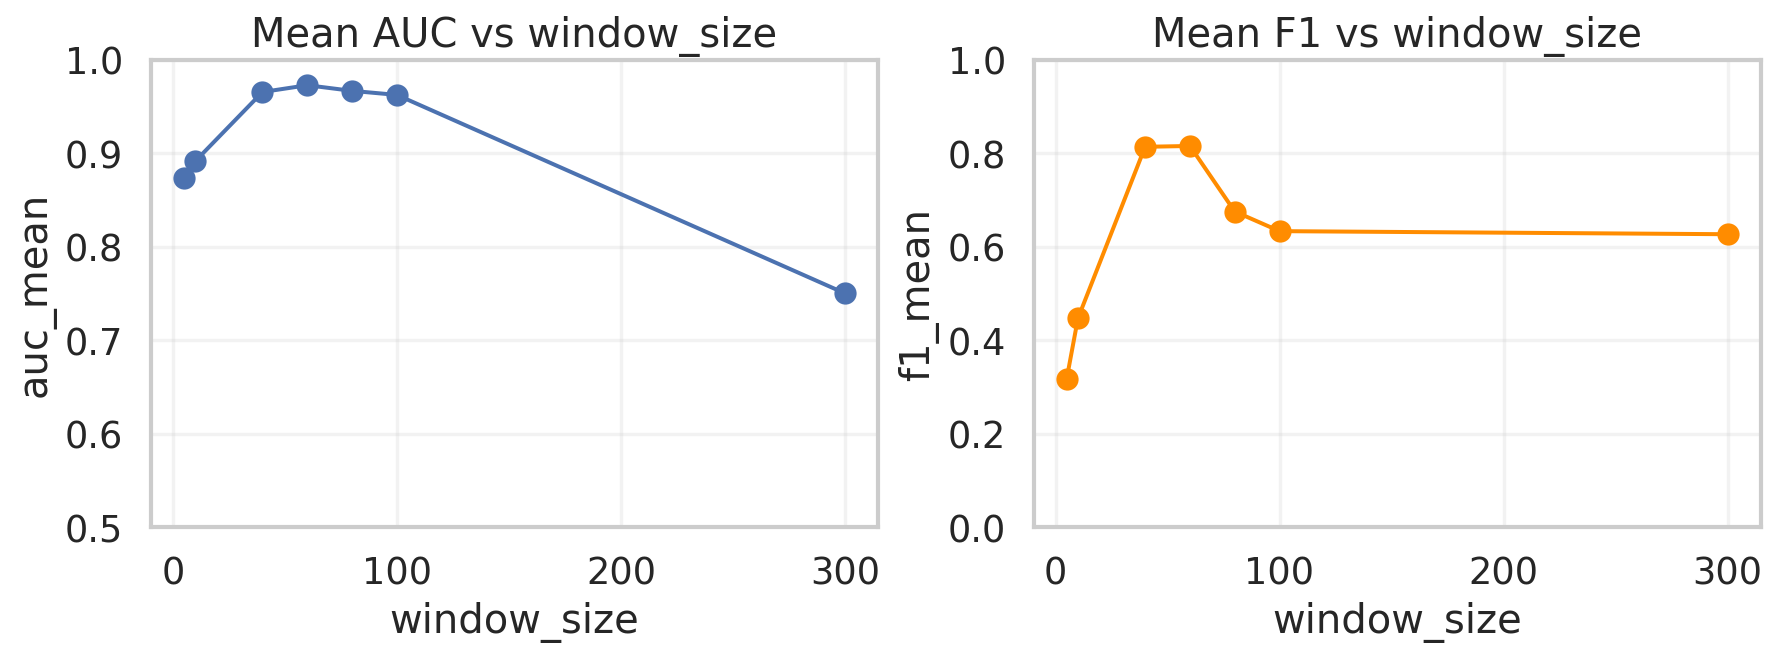

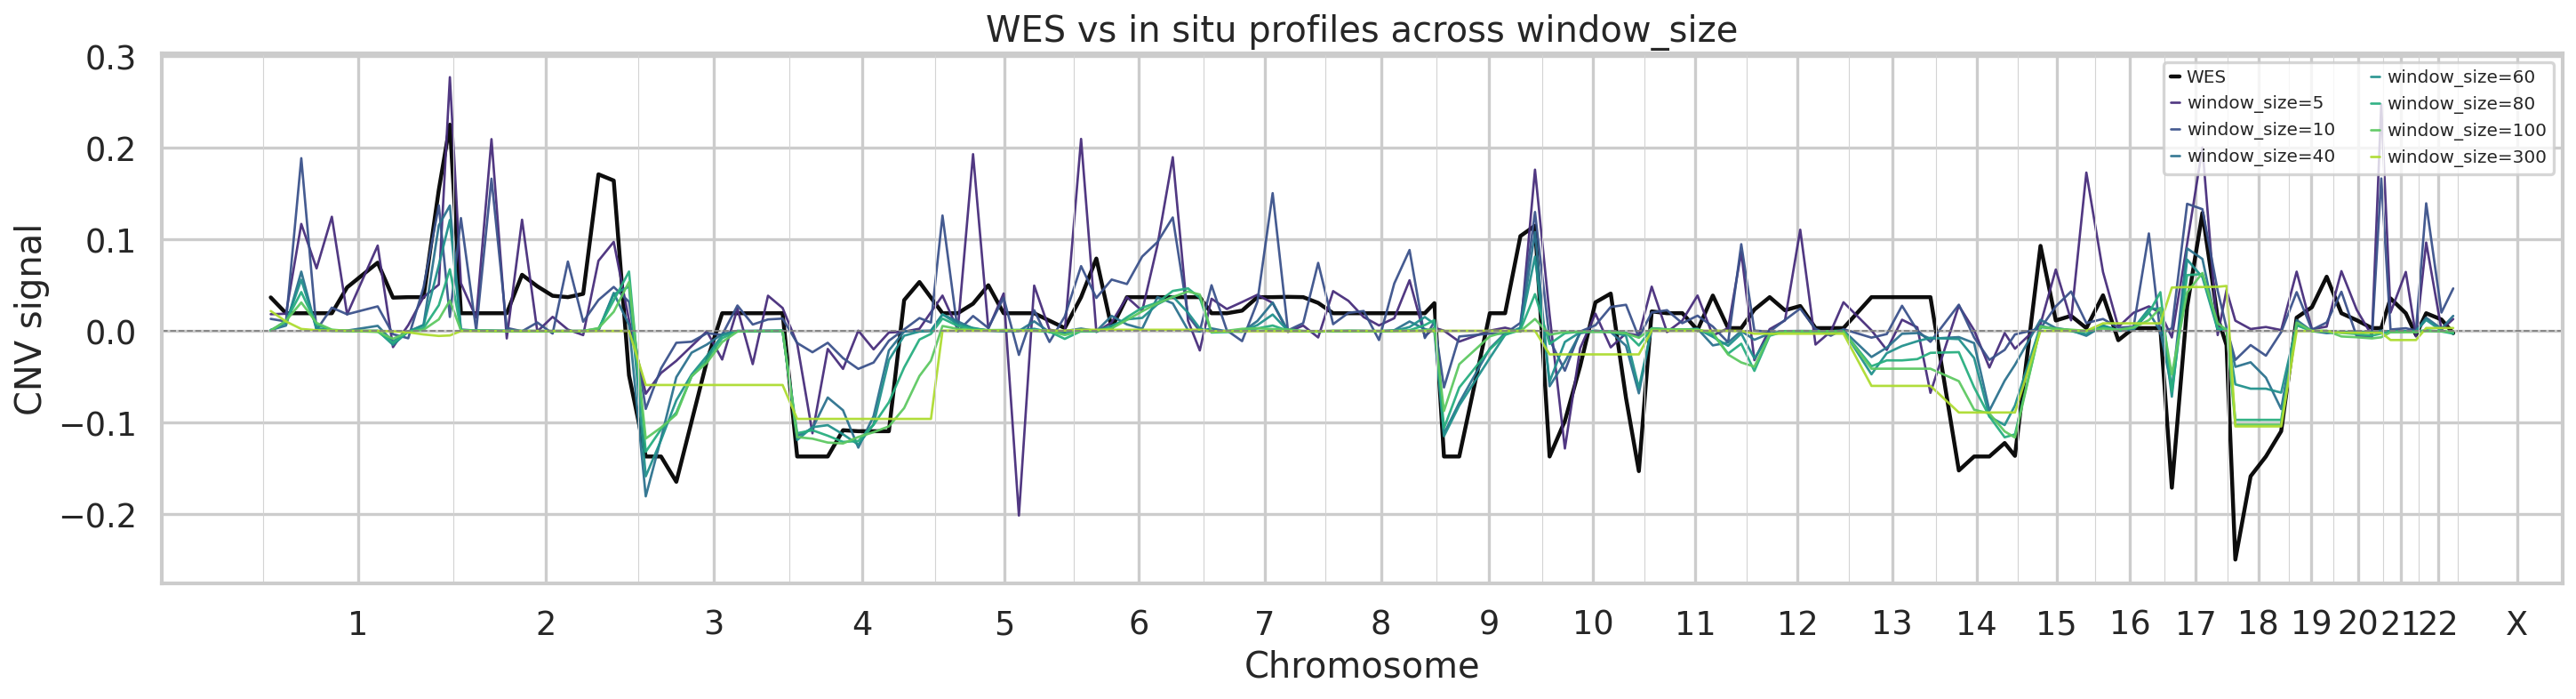

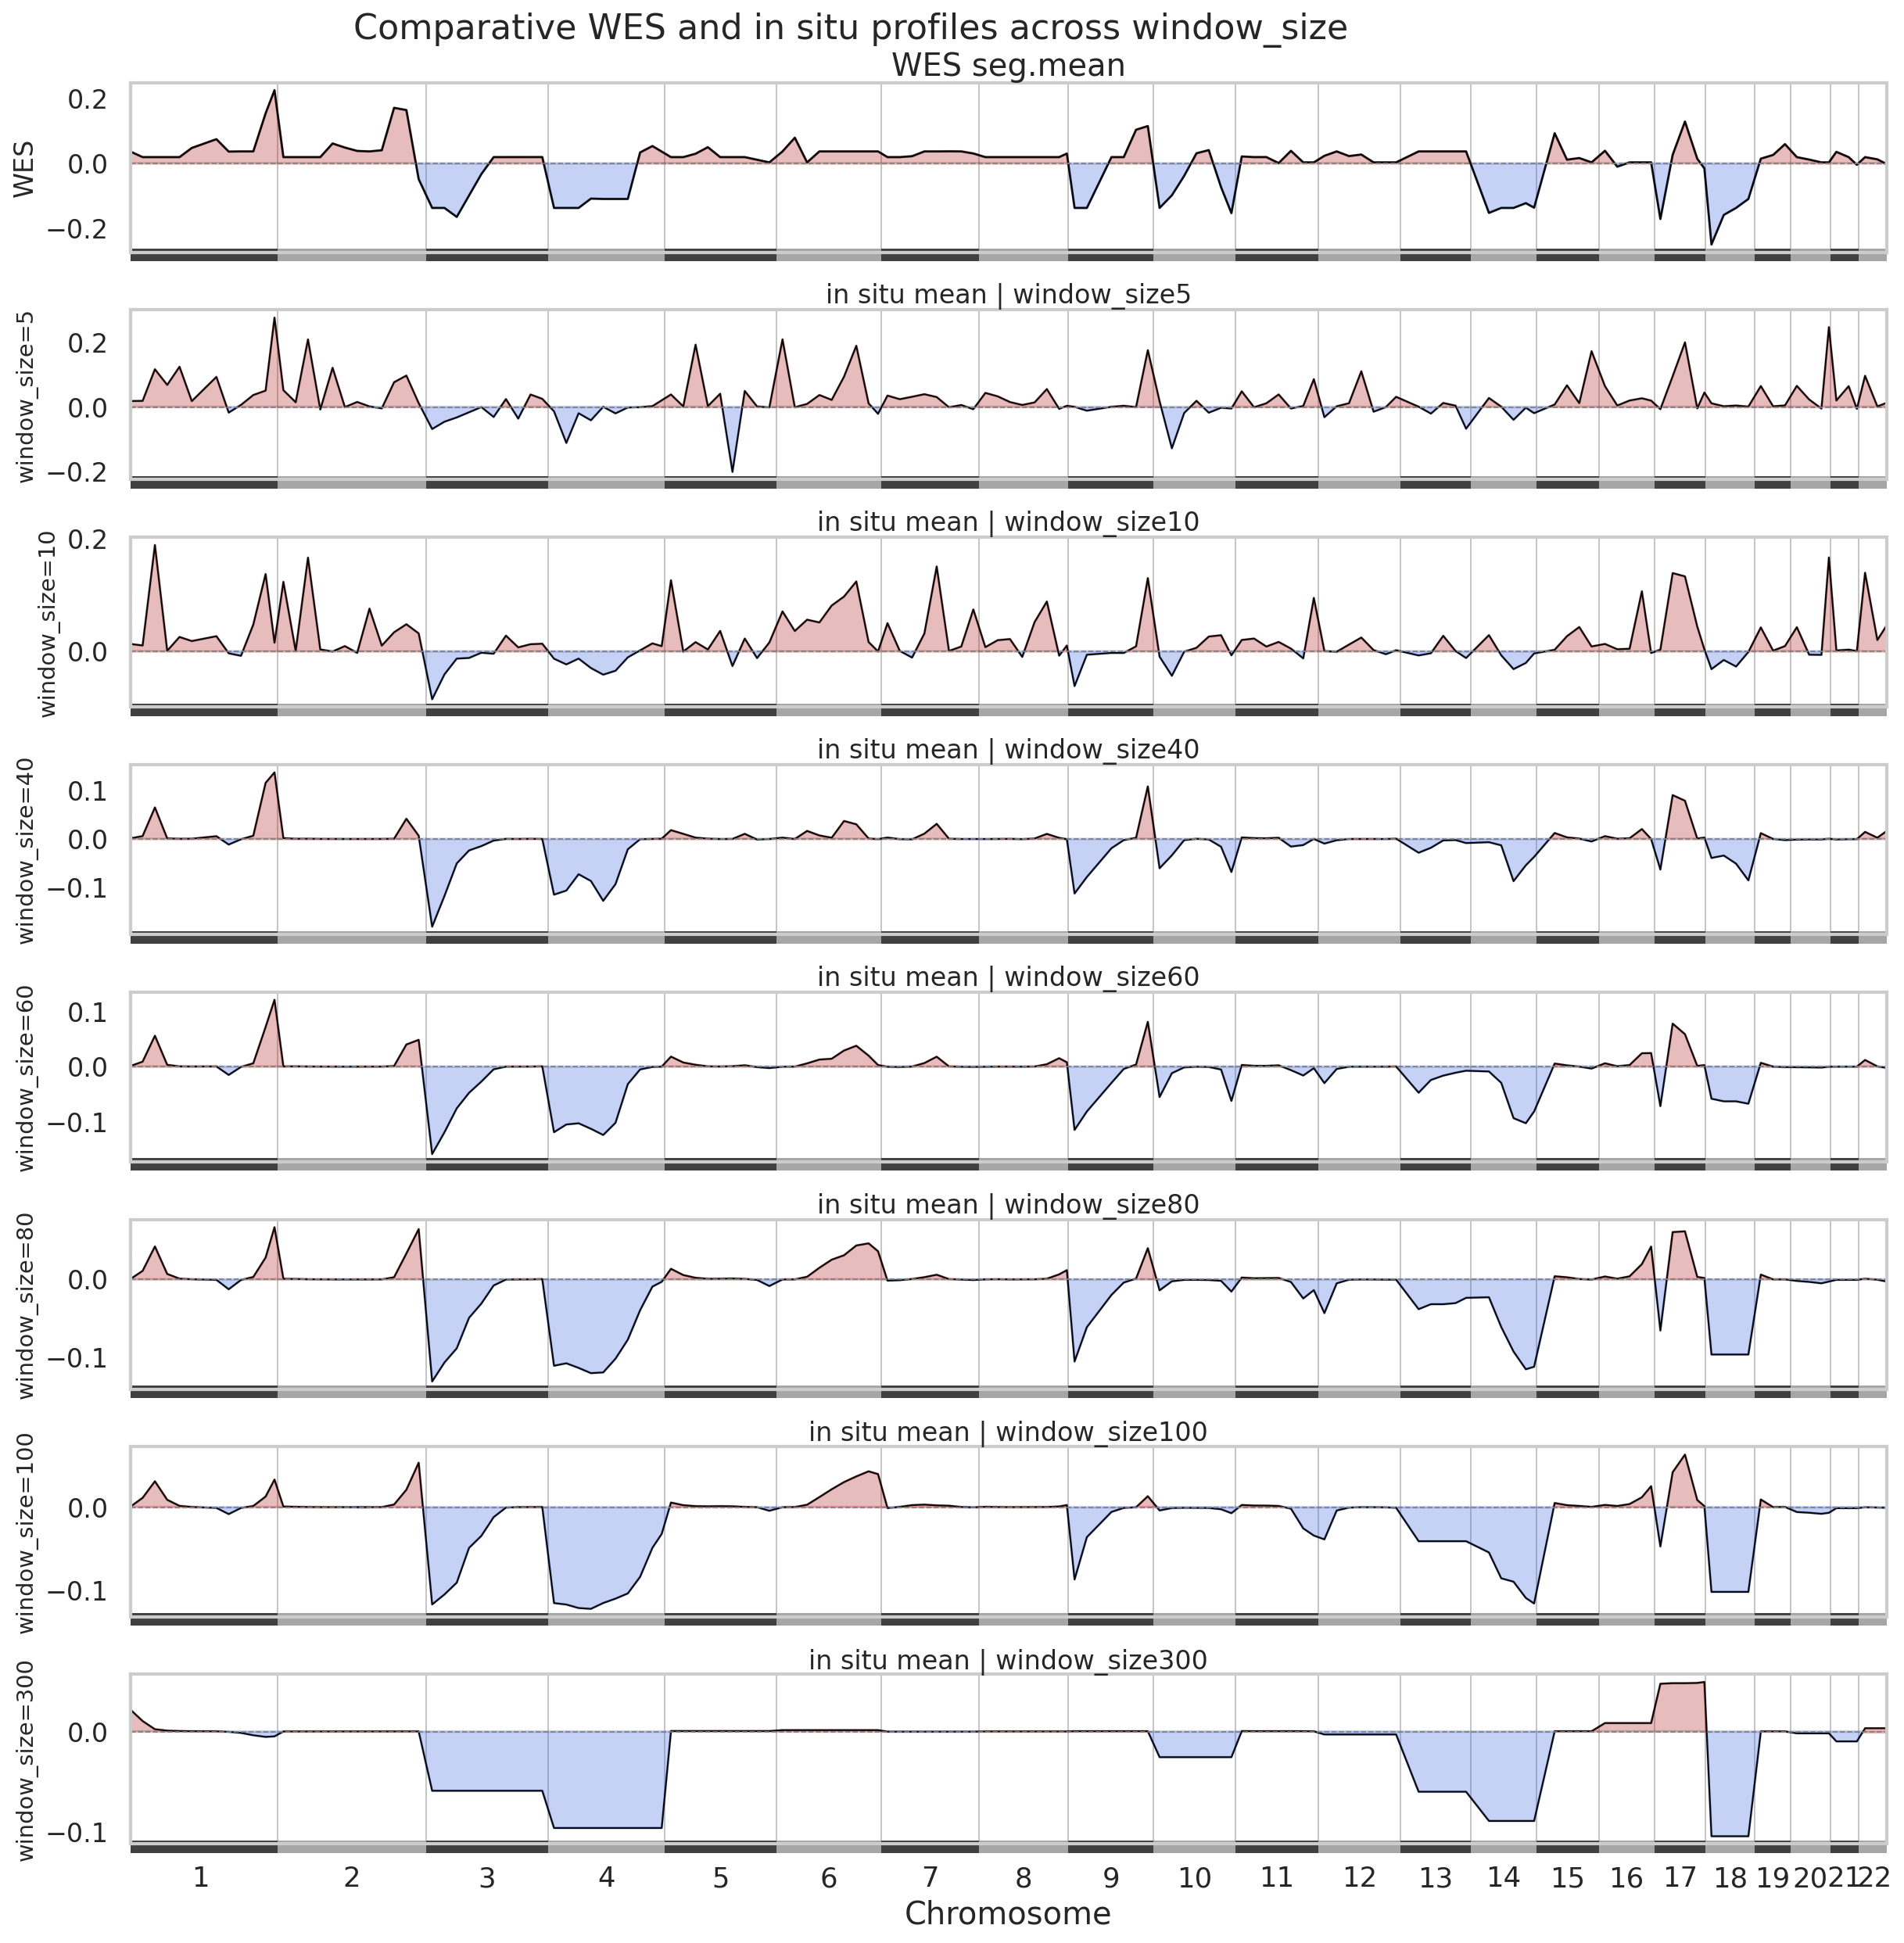

Saved summary files:
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_window_sizes/results/wes_vs_insitu_metrics/1105BL__all_runs__all_runs_metrics_summary.csv
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_window_sizes/results/wes_vs_insitu_metrics/1105BL__all_runs__all_runs_wes_threshold_auc_grid.csv
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_window_sizes/results/wes_vs_insitu_metrics/1105BL__all_runs__all_runs_insitu_threshold_f1_grid.csv
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_window_sizes/results/wes_vs_insitu_metrics/1105BL__all_runs__window_size_metric_bars.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_window_sizes/results/wes_vs_insitu_metrics/1105BL__all_runs__window_s

In [5]:
plot_parameter_metric_bars(
    metrics_df=all_metrics_df,
    parameter_name=parameter_name,
    parameter_label=parameter_label,
    output_dir=output_dir,
    sample_name=sample_name,
    run_label='all_runs',
)

plot_parameter_threshold_curves(
    metrics_df=all_metrics_df,
    truth_grid_df=all_wes_grid_df,
    pred_grid_df=all_insitu_grid_df,
    parameter_name=parameter_name,
    parameter_label=parameter_label,
    output_dir=output_dir,
    sample_name=sample_name,
    run_label='all_runs',
)

plot_parameter_metric_summary(
    metrics_df=all_metrics_df,
    parameter_name=parameter_name,
    parameter_label=parameter_label,
    output_dir=output_dir,
    sample_name=sample_name,
    run_label='all_runs',
)

plot_multi_run_profile_lines(
    run_results=run_results,
    parameter_name=parameter_name,
    parameter_label=parameter_label,
    output_dir=output_dir,
    sample_name=sample_name,
    run_label='all_runs',
)

plot_multi_run_profile_stack(
    run_results=run_results,
    parameter_name=parameter_name,
    parameter_label=parameter_label,
    output_dir=output_dir,
    sample_name=sample_name,
    run_label='all_runs',
)

print('Saved summary files:')
for stem, suffix in [
    ('all_runs_metrics_summary', '.csv'),
    ('all_runs_wes_threshold_auc_grid', '.csv'),
    ('all_runs_insitu_threshold_f1_grid', '.csv'),
    ('window_size_metric_bars', '.pdf'),
    ('window_size_threshold_curves', '.pdf'),
    ('window_size_metric_summary', '.pdf'),
    ('window_size_comparison_lines', '.pdf'),
    ('window_size_comparison_stack', '.pdf'),
]:
    print(' ', build_output_path(output_dir, sample_name, stem, suffix, run_label='all_runs'))
